In [1]:
import sys, importlib, os, inspect

NEW_ROOT = "/blue_npadillacoreano/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory"
OLD_ROOT = "/blue/npadillacoreano/t.heeps/rehouse_code/ephys_analysis"

os.chdir('/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys') # seems to be the only real fix

import importlib
import pickle

import behavior.boris_extraction as boris
from spike.spike_analysis.spike_collection import SpikeCollection
import trodes.read_exported as tr

import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path


print("behavior package from:", boris.__file__)
print("boris_extraction from:", inspect.getfile(boris))
print("trodes read_exported from: ", inspect.getfile(tr))

rec_subj_dict_path = "/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/d0_d7_rec_subj_dict"
event_dict_path = "/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/allsubjs_dict_d0_d7.pkl"
phy_recs = "/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/data_rehouse/phy_recs"

behavior package from: /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/behavior/boris_extraction.py
boris_extraction from: /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/behavior/boris_extraction.py
trodes read_exported from:  /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/trodes/read_exported.py


In [2]:
import spike.spike_analysis.spike_recording as sr
import spike.spike_analysis.firing_rate_calculations as fr
import spike.spike_analysis.normalization as norm
import spike.spike_analysis.single_cell as single_cell
import behavior.behavioral_epoch_tools as betools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import behavior.boris_extraction as boris
import matplotlib.pyplot as plt
import pickle
import re
import seaborn as sns

# Set global seaborn style
sns.set_context("notebook", font_scale=1.9)

# Define color palette for Day 0 (Teal) and Day 7 (Magenta)
COLOR_DAY0 = '#53A1A9'  # Teal
COLOR_DAY7 = '#A95376'  # Magenta

In [3]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


In [4]:
try:
    with open(rec_subj_dict_path, 'rb') as file:
        rec_subj_dict = pickle.load(file)
            
except FileNotFoundError:
    print("filenotfound")
rec_subj_dict

{'22_rehouse_d0_merged.rec': '22',
 '22_rehouse_d7_merged.rec': '22',
 '23_rehouse_d0_merged.rec': '23',
 '23_rehouse_d7_merged.rec': '23',
 '31_rehouse_d0_merged.rec': '31',
 '31_rehouse_d7_merged.rec': '31',
 '32_rehouse_d0_merged.rec': '32',
 '32_rehouse_d7_merged.rec': '32',
 '41_rehouse_d0_merged.rec': '41',
 '41_rehouse_d7_merged.rec': '41',
 '44_rehouse_d0_merged.rec': '44',
 '44_rehouse_d7_merged.rec': '44'}

In [5]:
try:
    with open(event_dict_path, 'rb') as file:
        event_dict = pickle.load(file)
            
except FileNotFoundError:
    print("filenotfound")
print(event_dict.keys())

dict_keys(['22_rehouse_d0_merged.rec', '22_rehouse_d7_merged.rec', '23_rehouse_d0_merged.rec', '23_rehouse_d7_merged.rec', '31_rehouse_d0_merged.rec', '31_rehouse_d7_merged.rec', '32_rehouse_d0_merged.rec', '32_rehouse_d7_merged.rec', '41_rehouse_d0_merged.rec', '41_rehouse_d7_merged.rec', '44_rehouse_d0_merged.rec', '44_rehouse_d7_merged.rec'])


In [6]:
event_dict['22_rehouse_d0_merged.rec'].keys()

dict_keys(['mice back in', 'sniffing object', 'mice taken out', 'anogenital sniffing', 'fighting', 'facial sniffing'])

In [7]:
for rec_name, ev_dict in event_dict.items():
    for ev_key, arr in ev_dict.items():
        if not isinstance(arr, np.ndarray):
            print(rec_name, ev_key, type(arr))
        elif arr.ndim != 2 or arr.shape[1] != 2:
            print(rec_name, ev_key, arr.shape)


In [8]:
import os

phy_recs = "/blue/npadillacoreano/t.heeps/npadillacoreano/share/rehouse_data/phy_recs"
for root, dirs, files in os.walk(phy_recs):
    print("ROOT:", root)
    print("DIRS:", dirs)
    break


ROOT: /blue/npadillacoreano/t.heeps/npadillacoreano/share/rehouse_data/phy_recs
DIRS: ['32_rehouse_d2_merged.rec', '32_rehouse_d7_merged.rec', '32_rehouse_d5_merged.rec', '22_rehouse_d7_merged.rec', '44_rehouse_d3_merged.rec', '22_rehouse_d3_merged.rec', '22_rehouse_d4_merged.rec', '44_rehouse_d7_merged.rec', '41_rehouse_d5_merged.rec', '32_rehouse_d4_merged.rec', '41_rehouse_d6_merged.rec', '32_rehouse_d1_merged.rec', '44_rehouse_d4_merged.rec', '31_rehouse_d7_merged.rec', '41_rehouse_d7_merged.rec', '22_rehouse_d6_merged.rec', '44_rehouse_d1_merged.rec', '44_rehouse_d2_merged.rec', '41_rehouse_d4_merged.rec', '41_rehouse_d3_merged.rec', '32_rehouse_d3_merged.rec', '22_rehouse_d2_merged.rec', '23_rehouse_d2_merged.rec', '44_rehouse_d0_merged.rec', '41_rehouse_d2_merged.rec', '22_rehouse_d0_merged.rec', '22_rehouse_d1_merged.rec', '41_rehouse_d1_merged.rec', '32_rehouse_d0_merged.rec', '41_rehouse_d0_merged.rec', '22_rehouse_d5_merged.rec', '44_rehouse_d5_merged.rec', '23_rehouse_d5_me

In [9]:
for event in event_dict['22_rehouse_d0_merged.rec']:
    print(event)

mice back in
sniffing object
mice taken out
anogenital sniffing
fighting
facial sniffing


# Replacing event dict with combined social sniffing and object sniffing by familiarity

In [10]:
# --- Loop through recordings ---
for rec_name, events in event_dict.items():
    # Check if relevant events exist
    has_facial = "facial sniffing" in events
    has_ano = "anogenital sniffing" in events

    # Combine the two if both (or even one) exist
    if has_facial or has_ano:
        combined_sniffing = []
        if has_facial:
            combined_sniffing.extend(events["facial sniffing"])
        if has_ano:
            combined_sniffing.extend(events["anogenital sniffing"])

        # Sort by time if your events are time intervals [(start, stop), ...]
        combined_sniffing = sorted(combined_sniffing, key=lambda x: x[0])

        # --- 🟩 Here's the key part ---
        # Unified event names so PCA sees the same structure in all recordings
        event_dict[rec_name] = {
            "social sniffing": np.array(combined_sniffing),
            "object sniffing": events.get("sniffing object"),
        }

        # --- 🟦 Add a label field for later plotting ---
        # (You can also store this in a parallel dict if you prefer)
        if "d0" in rec_name:
            event_dict[rec_name]["label"] = "novel"
        elif "d7" in rec_name:
            event_dict[rec_name]["label"] = "fam"


In [11]:
sc = SpikeCollection(phy_recs, event_dict, rec_subj_dict)

--skipping--
loading  32_rehouse_d7_merged.rec
--skipping--
loading  22_rehouse_d7_merged.rec
--skipping--
--skipping--
--skipping--
loading  44_rehouse_d7_merged.rec
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--
loading  31_rehouse_d7_merged.rec
loading  41_rehouse_d7_merged.rec
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--
loading  44_rehouse_d0_merged.rec
--skipping--
loading  22_rehouse_d0_merged.rec
--skipping--
--skipping--
loading  32_rehouse_d0_merged.rec
loading  41_rehouse_d0_merged.rec
Unit 163 is unsorted & has 1202 spikes
Unit 163 will be deleted
Unit 153 is unsorted & has 4386 spikes
Unit 153 will be deleted
Unit 157 is unsorted & has 652 spikes
Unit 157 will be deleted
Unit 162 is unsorted & has 34 spikes
Unit 162 will be deleted
--skipping--
--skipping--
--skipping--
--skipping--
--skipping--


In [12]:
sc.analyze(timebin=100, ignore_freq=0.5, smoothing_window = 500)

Your event dictionary keys are different across recordings.
Please double check them:
32_rehouse_d7_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
22_rehouse_d7_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
44_rehouse_d7_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
31_rehouse_d7_merged.rec keys: dict_keys(['mice back in', 'fighting', 'mice taken out', 'sniffing object'])
41_rehouse_d7_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
44_rehouse_d0_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
22_rehouse_d0_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
32_rehouse_d0_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
41_rehouse_d0_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])


In [13]:
'''
# ============================================================================
# FILTER RECORDINGS: Keep only subjects with BOTH d0 AND d7
# ============================================================================
print("="*80)
print("FILTERING RECORDINGS TO ENSURE PAIRED d0/d7 DATA")
print("="*80)

# Extract subject IDs and days from all recordings
subjects_by_day = {'d0': set(), 'd7': set()}

for rec in sc.recordings:
    rec_name = rec.name
    # Extract subject number (e.g., "22" from "22_rehouse_d0_merged.rec")
    subject_match = re.match(r'(\d+)_', rec_name)
    if subject_match:
        subject_id = subject_match.group(1)
        
        # Determine day
        if '_d0_' in rec_name or rec_name.endswith('_d0.rec'):
            subjects_by_day['d0'].add(subject_id)
        elif '_d7_' in rec_name or rec_name.endswith('_d7.rec'):
            subjects_by_day['d7'].add(subject_id)

print(f"\nSubjects with d0 recordings: {sorted(subjects_by_day['d0'])}")
print(f"Subjects with d7 recordings: {sorted(subjects_by_day['d7'])}")

# Find subjects that have BOTH d0 and d7
subjects_with_both = subjects_by_day['d0'] & subjects_by_day['d7']
subjects_missing_d0 = subjects_by_day['d7'] - subjects_by_day['d0']
subjects_missing_d7 = subjects_by_day['d0'] - subjects_by_day['d7']

print(f"\n✓ Subjects with BOTH d0 and d7: {sorted(subjects_with_both)}")
if subjects_missing_d0:
    print(f"⚠️ Subjects missing d0 (will be EXCLUDED): {sorted(subjects_missing_d0)}")
if subjects_missing_d7:
    print(f"⚠️ Subjects missing d7 (will be EXCLUDED): {sorted(subjects_missing_d7)}")

# Filter recordings to keep only those from subjects with both days
original_count = len(sc.recordings)
filtered_recordings = []
excluded_recordings = []

for rec in sc.recordings:
    rec_name = rec.name
    subject_match = re.match(r'(\d+)_', rec_name)
    if subject_match:
        subject_id = subject_match.group(1)
        if subject_id in subjects_with_both:
            filtered_recordings.append(rec)
        else:
            excluded_recordings.append(rec_name)
    else:
        # Keep recordings without clear subject ID pattern (shouldn't happen)
        filtered_recordings.append(rec)

# Update the SpikeCollection with filtered recordings
sc.recordings = filtered_recordings

if excluded_recordings:
    print(f"\nExcluded recordings:")
    for rec_name in excluded_recordings:
        print(f"  - {rec_name}")

print(f"\n✓ Analysis will proceed with {len(subjects_with_both)} subjects (paired d0/d7)")
print("="*80)
'''

'\n# ============================================================================\n# FILTER RECORDINGS: Keep only subjects with BOTH d0 AND d7\n# ============================================================================\nprint("="*80)\nprint("FILTERING RECORDINGS TO ENSURE PAIRED d0/d7 DATA")\nprint("="*80)\n\n# Extract subject IDs and days from all recordings\nsubjects_by_day = {\'d0\': set(), \'d7\': set()}\n\nfor rec in sc.recordings:\n    rec_name = rec.name\n    # Extract subject number (e.g., "22" from "22_rehouse_d0_merged.rec")\n    subject_match = re.match(r\'(\\d+)_\', rec_name)\n    if subject_match:\n        subject_id = subject_match.group(1)\n        \n        # Determine day\n        if \'_d0_\' in rec_name or rec_name.endswith(\'_d0.rec\'):\n            subjects_by_day[\'d0\'].add(subject_id)\n        elif \'_d7_\' in rec_name or rec_name.endswith(\'_d7.rec\'):\n            subjects_by_day[\'d7\'].add(subject_id)\n\nprint(f"\nSubjects with d0 recordings: {sorted(subj

In [14]:
sc.recordings

Text(0, 0.5, 'Count')

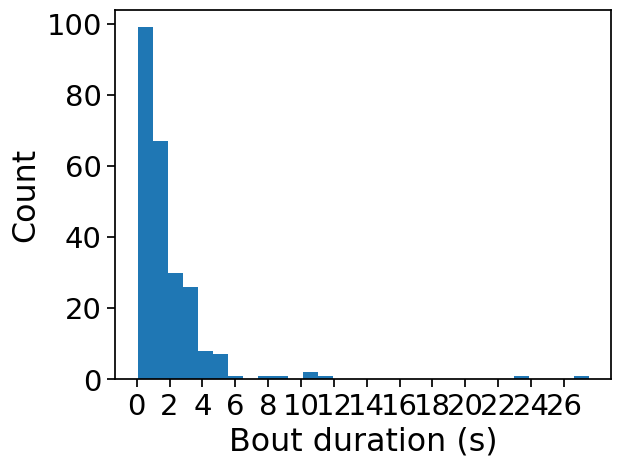

In [15]:
all_durations = []
for rec in sc.recordings:
    for ev, arr in rec.event_dict.items():
        if ev == "social sniffing":  # or whichever
            all_durations.extend(arr[:,1] - arr[:,0])
plt.hist(np.array(all_durations)/1000, bins=30)
plt.xticks(np.arange(0, max(all_durations)/1000, 2))
plt.xlabel("Bout duration (s)")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

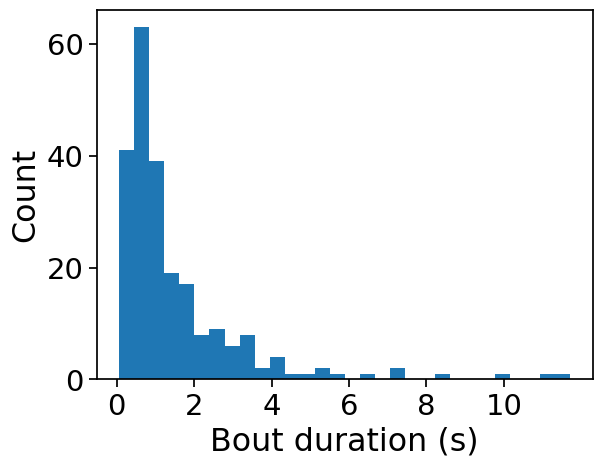

In [16]:

all_durations = []
for rec in sc.recordings:
    for ev, arr in rec.event_dict.items():
        if ev == "object sniffing":  # or whichever
            all_durations.extend(arr[:,1] - arr[:,0])
plt.hist(np.array(all_durations)/1000, bins=30)
plt.xticks(np.arange(0, max(all_durations)/1000, 2))
plt.xlabel("Bout duration (s)")
plt.ylabel("Count")

# Preprocessing Done, Organizing for PCA/Decoding Analysis

### organize novel and familiar recordings novel -> recording name -> recording object

In [17]:
sc.recordings[0].event_dict.keys()

dict_keys(['social sniffing', 'object sniffing', 'label'])

In [18]:
import spike.spike_analysis.decoders as dec
import spike.spike_analysis.pca_trajectories as pca_traj

In [19]:
for rec in sc.recordings:
    for event, val in rec.event_dict.items():
        print(f"{rec.name}: {event}, {len(val)}")

32_rehouse_d7_merged.rec: social sniffing, 36
32_rehouse_d7_merged.rec: object sniffing, 32
32_rehouse_d7_merged.rec: label, 3
22_rehouse_d7_merged.rec: social sniffing, 24
22_rehouse_d7_merged.rec: object sniffing, 21
22_rehouse_d7_merged.rec: label, 3
44_rehouse_d7_merged.rec: social sniffing, 28
44_rehouse_d7_merged.rec: object sniffing, 22
44_rehouse_d7_merged.rec: label, 3
31_rehouse_d7_merged.rec: mice back in, 1
31_rehouse_d7_merged.rec: fighting, 3
31_rehouse_d7_merged.rec: mice taken out, 1
31_rehouse_d7_merged.rec: sniffing object, 1
41_rehouse_d7_merged.rec: social sniffing, 37
41_rehouse_d7_merged.rec: object sniffing, 14
41_rehouse_d7_merged.rec: label, 3
44_rehouse_d0_merged.rec: social sniffing, 37
44_rehouse_d0_merged.rec: object sniffing, 56
44_rehouse_d0_merged.rec: label, 5
22_rehouse_d0_merged.rec: social sniffing, 29
22_rehouse_d0_merged.rec: object sniffing, 33
22_rehouse_d0_merged.rec: label, 5
32_rehouse_d0_merged.rec: social sniffing, 4
32_rehouse_d0_merged.rec

Excluding 32_rehouse_d7_merged.rec with 4 neurons
Excluding 31_rehouse_d7_merged.rec with 3 neurons
Excluding 44_rehouse_d0_merged.rec with 4 neurons


/blue/npadillacoreano/t.heeps/.conda/envs/lfp_export_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


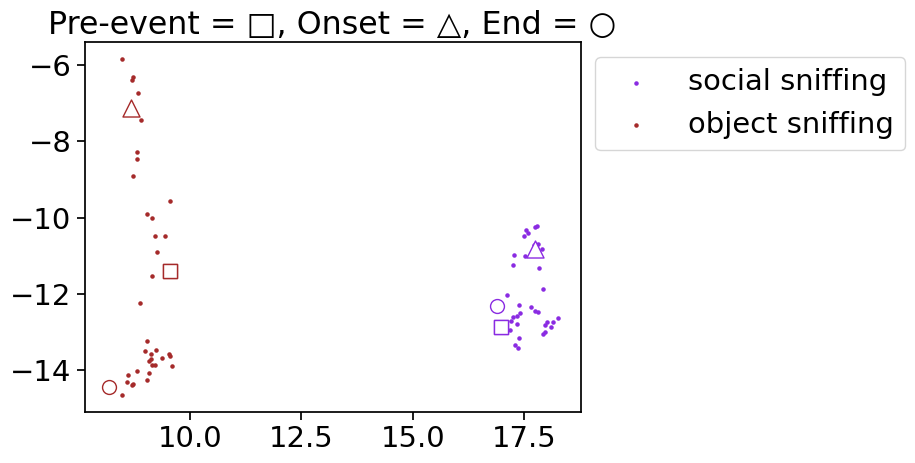

In [20]:
events = ["social sniffing", "object sniffing"]
pca2_result = pca_traj.avg_trajectories_pca(sc, 3, 1, min_neurons=5, events=events)

In [21]:
def plot_pca_results_3d(pca_result, title, colors, azim, elev, save = False):
    event_lengths = int(
            (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
        )
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    PCA_matrix = pca_result.transformed_data
    col_counter = 0
    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(111, projection="3d")
    #plt.subplots_adjust(left=0.3, right=0.99, bottom=0.1, top=0.9)
    for i in range(0, len(PCA_key), event_lengths):
        event_label = PCA_key[i]
        onset = int(i + pre_window - 1)
        end = int(i + event_end - 1)
        post = int(i + event_lengths - 1)
        ax.plot3D(
            PCA_matrix[i : i + event_lengths, 0],
            PCA_matrix[i : i + event_lengths, 1],
            PCA_matrix[i : i + event_lengths, 2],
            label=event_label,
            color=colors[col_counter],
            linewidth = 5,
            alpha = 0.8
        )
        ax.scatter(
            PCA_matrix[i, 0],
            PCA_matrix[i, 1],
            PCA_matrix[i, 2],
            marker="s",
            s=100,
            c="w",
            edgecolors=colors[col_counter],
        )
        ax.scatter(
            PCA_matrix[onset, 0],
            PCA_matrix[onset, 1],
            PCA_matrix[onset, 2],
            marker="^",
            s=300,
            c="w",
            edgecolors=colors[col_counter],
        )
        ax.scatter(
            PCA_matrix[end, 0],
            PCA_matrix[end, 1],
            PCA_matrix[end, 2],
            marker="o",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
        )
        if post_window != 0:
            print("woo")
            ax.scatter(
                PCA_matrix[post, 0],
                PCA_matrix[post, 1],
                PCA_matrix[post, 2],
                marker="D",
                s=200,
                c="w",
                edgecolors=colors[col_counter],
            )
        col_counter += 1
    ax.legend(loc="upper left", bbox_to_anchor=(.9,1), frameon = False, fontsize = 14)
    # ax.set_xlim(-20, 45)
    # ax.set_ylim(-5, 25)
    # ax.set_zlim(-20, 30)
    ax.view_init(azim = azim, elev =elev)
    ax.set_title(f"{title}", fontsize = 24, y = 1)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% variance)", fontsize = 16, labelpad = -10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.yaxis.pane.set_alpha(0.9)
    ax.xaxis.pane.set_alpha(0.9)
    ax.zaxis.pane.set_alpha(0.9)
    plt.tight_layout()
    if save:
        plt.savefig(f'{title}.png', dpi = 600, transparent = True,bbox_inches='tight' )
    plt.show()


def plot_pca_results_2d(pca_result, title, colors, legend_spot, save=False):
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    PCA_matrix = pca_result.transformed_data
    col_counter = 0
    
    # Create figure with updated size
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    
    for i in range(0, len(PCA_key), event_lengths):
        event_label = PCA_key[i]
        onset = int(i + pre_window - 1)
        end = int(i + event_end - 1)
        post = int(i + event_lengths - 1)
        
        # Plot the continuous line with updated styling
        ax.plot(
            PCA_matrix[i:i + event_lengths, 0],
            PCA_matrix[i:i + event_lengths, 1],
            label=event_label,
            color=colors[col_counter],
            linewidth=5,
            alpha=0.8,
            zorder = 1
        )
        
        # Add markers with updated sizes
        ax.scatter(
            PCA_matrix[i, 0],
            PCA_matrix[i, 1],
            marker="s",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
            zorder = 2
        )
        ax.scatter(
            PCA_matrix[onset, 0],
            PCA_matrix[onset, 1],
            marker="^",
            s=300,
            c="w",
            edgecolors=colors[col_counter],
            zorder = 3
        )
        ax.scatter(
            PCA_matrix[end, 0],
            PCA_matrix[end, 1],
            marker="o",
            s=200,
            c="w",
            edgecolors=colors[col_counter],
            zorder = 4
        )
        if post_window != 0:
            ax.scatter(
                PCA_matrix[post, 0],
                PCA_matrix[post, 1],
                marker="D",
                s=200,
                c="w",
                edgecolors=colors[col_counter],
                zorder =5
            )
        col_counter += 1
    
    # Updated legend formatting
    ax.legend(loc="upper left", bbox_to_anchor=legend_spot, frameon=False, fontsize=14)
    
    # ax.set_xlim(-20, 45)
    # ax.set_ylim(-5, 25)
    
    # Updated title and label formatting
    ax.set_title(f"{title}", fontsize=24, y=1.01)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% variance)", fontsize=16)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% variance)", fontsize=16)
    
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xticks([])
    
    # Add tight layout
    plt.tight_layout()
    
    if save:
        plt.savefig(f'{title}.png', dpi=600, transparent=True, bbox_inches='tight')
    plt.show()

In [22]:
def hex_2_rgb(hex_color): # Orange color
    rgb_color = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (1, 3, 5))
    return rgb_color

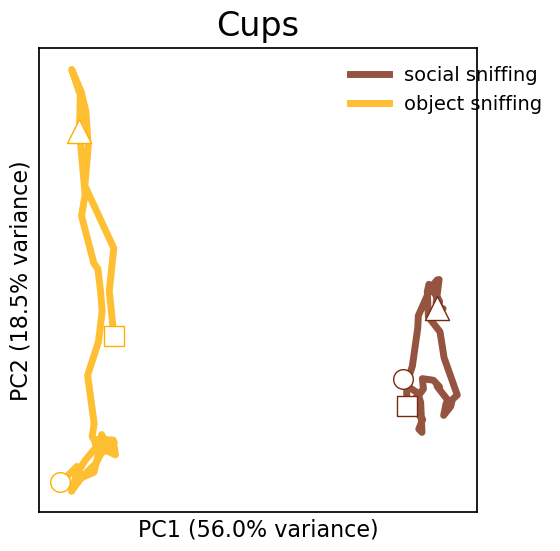

In [23]:
color_id_dict = {'social sniffing': hex_2_rgb('#15616F'), 
                'object sniffing': (1.0, 0.6862745098039216, 0.0)}
plot_pca_results_2d(pca_result=pca2_result, title = 'Cups', colors = [hex_2_rgb('#792910'),
                                                             (1.0, 0.6862745098039216, 0.0),
                                                             hex_2_rgb('#15616F'),
                                                             'black'], legend_spot = (0.67, 1))
#plot_pca_results_3d(pca_result=pca_result, title = 'Cups', colors = [hex_2_rgb('#792910'),
#                                                              (1.0, 0.6862745098039216, 0.0),
#                                                              hex_2_rgb('#15616F'),
#                                                              'black'], azim = 60, elev = 30)  

# Condition based PCA

In [24]:
sc.analyze(timebin=50, ignore_freq=0.5, smoothing_window = 500)

Your event dictionary keys are different across recordings.
Please double check them:
32_rehouse_d7_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
22_rehouse_d7_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
44_rehouse_d7_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
31_rehouse_d7_merged.rec keys: dict_keys(['mice back in', 'fighting', 'mice taken out', 'sniffing object'])
41_rehouse_d7_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
44_rehouse_d0_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
22_rehouse_d0_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
32_rehouse_d0_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])
41_rehouse_d0_merged.rec keys: dict_keys(['social sniffing', 'object sniffing', 'label'])


In [25]:
importlib.reload(pca_traj)

<module 'spike.spike_analysis.pca_trajectories' from '/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/spike/spike_analysis/pca_trajectories.py'>

Excluding 32_rehouse_d7_merged.rec with 4 neurons
Excluding 31_rehouse_d7_merged.rec with 3 neurons
Excluding 44_rehouse_d0_merged.rec with 4 neurons


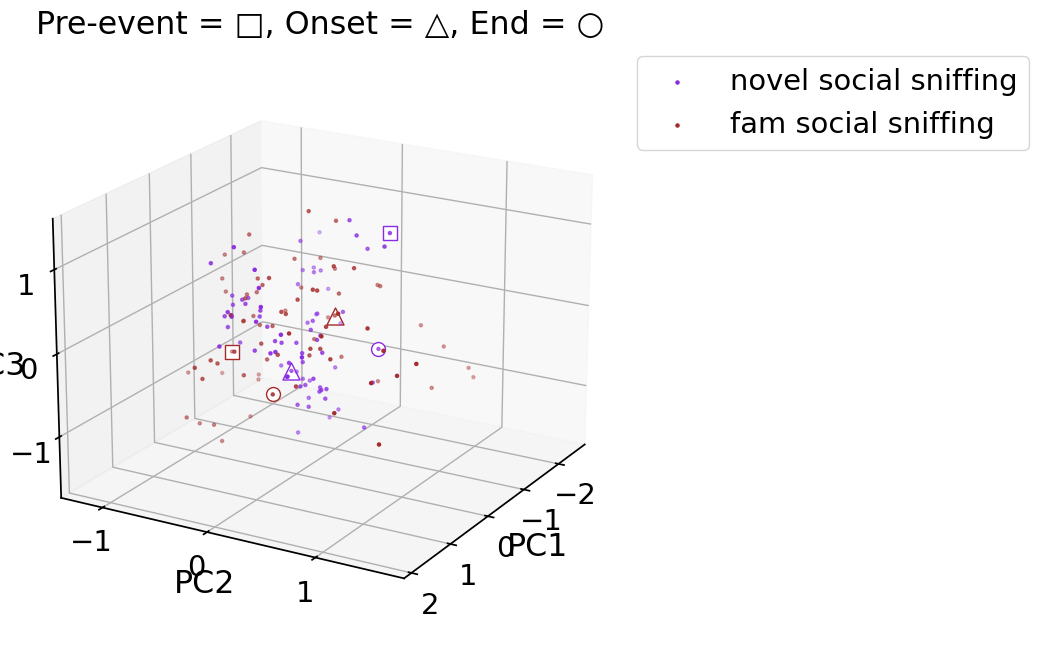

In [26]:
condition_dict = {
    "novel": [rec_name for rec_name in event_dict.keys() if "d0" in rec_name],
    "fam": [rec_name for rec_name in event_dict.keys() if "d7" in rec_name],
}

events = ["social sniffing"]

pca2_result = pca_traj.condition_pca(
    sc,
    condition_dict=condition_dict,
    event_length=3,
    pre_window=1,
    min_neurons=5,
    events=events,
    d=3,
)

/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/spike/spike_analysis/pca_trajectories.py:1039: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


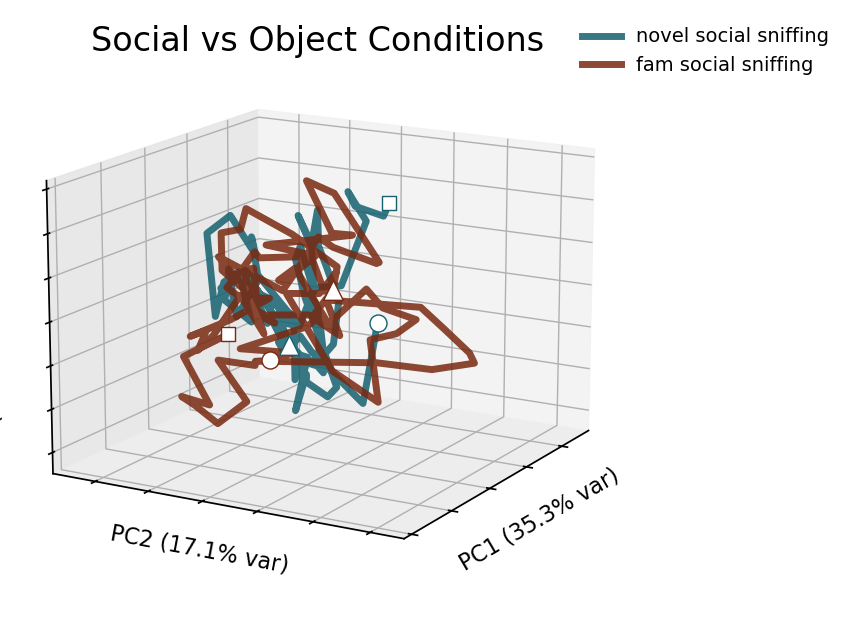

In [29]:
pca_traj.plot_condition_pca_results_3d(
    pca_result=pca2_result,
    title="Social vs Object Conditions",
    colors=[hex_2_rgb('#15616F'), hex_2_rgb('#792910'), 'black', (1.0, 0.686, 0.0)],
    azim=30, elev=15
)

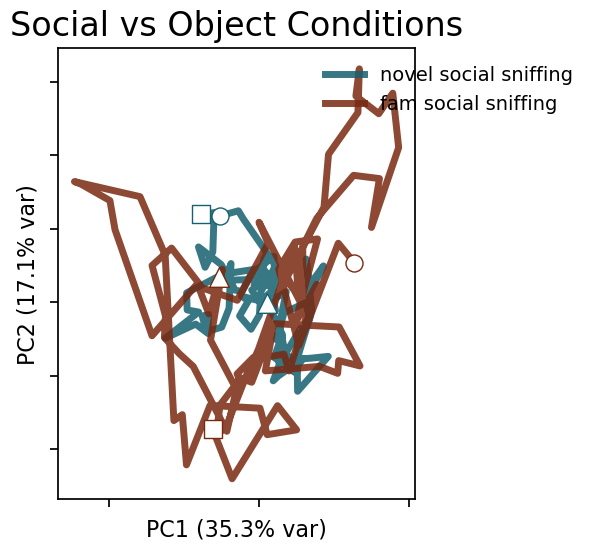

In [34]:
pca_traj.plot_condition_pca_results_2d(
    pca_result=pca2_result,
    title="Social vs Object Conditions",
    colors=[hex_2_rgb('#15616F'), hex_2_rgb('#792910'), 'black', (1.0, 0.686, 0.0)],
)

In [433]:
print(condition_dict)

{'novel': ['22_rehouse_d0_merged.rec', '23_rehouse_d0_merged.rec', '31_rehouse_d0_merged.rec', '32_rehouse_d0_merged.rec', '41_rehouse_d0_merged.rec', '44_rehouse_d0_merged.rec'], 'fam': ['22_rehouse_d7_merged.rec', '23_rehouse_d7_merged.rec', '31_rehouse_d7_merged.rec', '32_rehouse_d7_merged.rec', '41_rehouse_d7_merged.rec', '44_rehouse_d7_merged.rec']}


social_novel: 4 recs
social_fam: 4 recs
object_novel: 4 recs
object_fam: 4 recs
Excluding 32_rehouse_d7_merged.rec with 4 neurons
Excluding 31_rehouse_d7_merged.rec with 3 neurons
Excluding 44_rehouse_d0_merged.rec with 4 neurons


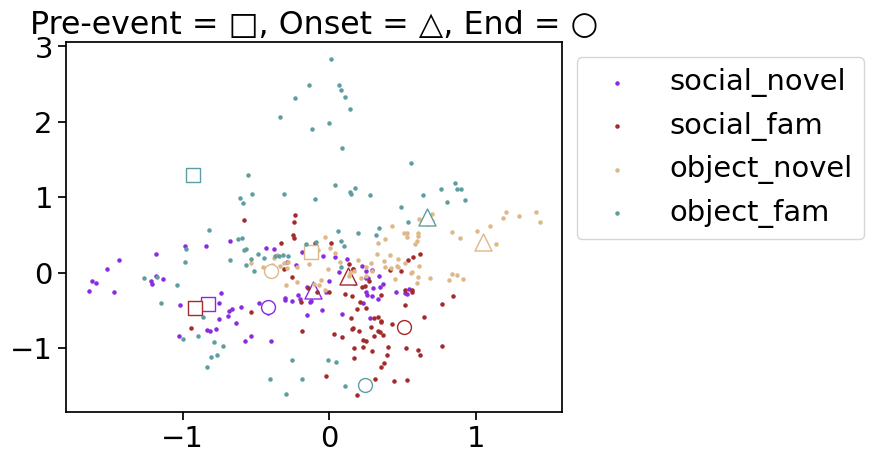

In [434]:
# ==========================================================
# PCA CONDITIONS: Only 4 true conditions (object/social × novel/fam)
# ==========================================================

import spike.spike_analysis.pca_trajectories as pca_traj

condition_dict = {
    "social_novel": [],
    "social_fam": [],
    "object_novel": [],
    "object_fam": []
}

# Build condition_dict with recordings that have the appropriate events
for rec in sc.recordings:
    rec_name = rec.name.lower()
    if "d0" in rec_name:
        fam_type = "novel"
    elif "d7" in rec_name:
        fam_type = "fam"
    else:
        continue

    # Check for social sniffing
    if (
        "social sniffing" in rec.event_dict
        and rec.event_dict["social sniffing"] is not None
        and len(rec.event_dict["social sniffing"]) > 0
    ):
        condition_dict[f"social_{fam_type}"].append(rec.name)

    # Check for object sniffing
    if (
        "object sniffing" in rec.event_dict
        and rec.event_dict["object sniffing"] is not None
        and len(rec.event_dict["object sniffing"]) > 0
    ):
        condition_dict[f"object_{fam_type}"].append(rec.name)

# ✅ Print to verify
for cond, recs in condition_dict.items():
    print(f"{cond}: {len(recs)} recs")

# ✅ KEY FIX: Create event mapping for each condition
condition_events = {
    "social_novel": ["social sniffing"],
    "social_fam": ["social sniffing"],
    "object_novel": ["object sniffing"],
    "object_fam": ["object sniffing"]
}

# Run PCA with ALL events (needed to build the full PCA space)
pca_cond_result = pca_traj.condition_pca(
    spike_collection=sc,
    condition_dict=condition_dict,
    event_length=3,
    pre_window=1,
    post_window=0,
    min_neurons=5,
    events=["social sniffing", "object sniffing"],  # All events for PCA space
    d=2,
    plot=False  # Don't use default plot
)

# ✅ Custom plotting that respects condition-event mapping
import matplotlib.pyplot as plt
import numpy as np

def condition_EDA_plot_fixed(pca_result, condition_events):
    """Plot only the relevant event for each condition"""
    event_length = pca_result.event_length
    pre_window = pca_result.pre_window
    post_window = pca_result.post_window
    condition_dict = pca_result.condition_dict
    PCA_key = pca_result.labels
    conv_factor = 1000 / pca_result.timebin
    pca_matrix = pca_result.transformed_data
    
    event_lengths = int((event_length + pre_window + post_window) * conv_factor)
    event_end = int((event_length + pre_window) * conv_factor)
    pre_window_bins = int(pre_window * conv_factor)
    post_window_bins = int(post_window * conv_factor)
    
    colors_dict = plt.cm.colors.CSS4_COLORS
    colors = list(colors_dict.values())
    col_counter = 10
    
    for condition in condition_dict.keys():
        relevant_events = condition_events.get(condition, [])
        
        for i in range(0, len(PCA_key), event_lengths):
            event_label = PCA_key[i]
            
            # ✅ ONLY PLOT IF THIS EVENT BELONGS TO THIS CONDITION
            if event_label not in relevant_events:
                continue
            
            onset = i if pre_window_bins == 0 else int(i + pre_window_bins - 1)
            end = int(i + event_end - 1)
            post = int(i + event_lengths - 1)
            
            plt.scatter(
                pca_matrix[condition][i : i + event_lengths, 0],
                pca_matrix[condition][i : i + event_lengths, 1],
                label=f"{condition}",  # Simplified label since event is implicit
                s=5,
                c=colors[col_counter],
            )
            
            # Add markers
            if pre_window_bins != 0:
                plt.scatter(
                    pca_matrix[condition][i, 0],
                    pca_matrix[condition][i, 1],
                    marker="s",
                    s=100,
                    c="w",
                    edgecolors=colors[col_counter],
                )
            plt.scatter(
                pca_matrix[condition][onset, 0],
                pca_matrix[condition][onset, 1],
                marker="^",
                s=150,
                c="w",
                edgecolors=colors[col_counter],
            )
            plt.scatter(
                pca_matrix[condition][end, 0],
                pca_matrix[condition][end, 1],
                marker="o",
                s=100,
                c="w",
                edgecolors=colors[col_counter],
            )
            if post_window_bins != 0:
                plt.scatter(
                    pca_matrix[condition][post, 0],
                    pca_matrix[condition][post, 1],
                    marker="D",
                    s=100,
                    c="w",
                    edgecolors=colors[col_counter],
                )
            col_counter += 1
    
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    post_win_text = ", Post = ◇" if post_window_bins != 0 else ""
    pre_win_text = "Pre-event = □, " if pre_window_bins != 0 else ""
    title = pre_win_text + "Onset = △, End = ○" + post_win_text
    plt.title(title)
    plt.show()

# Use the fixed plotting function
condition_EDA_plot_fixed(pca_cond_result, condition_events)

In [435]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_results_3d(pca_result, title, colors, azim, elev, condition_events=None, save=False):
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    condition_dict = pca_result.condition_dict
    PCA_matrix = pca_result.transformed_data
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    col_counter = 0

    for condition, data in PCA_matrix.items():
        relevant_events = condition_events.get(condition, []) if condition_events else []
        matching_indices = [i for i in range(0, len(PCA_key), event_lengths) if PCA_key[i] in relevant_events]
        
        if not matching_indices:
            continue
        
        trajectories = [data[idx:idx + event_lengths, :] for idx in matching_indices]
        avg_trajectory = np.mean(trajectories, axis=0)
        
        onset = int(pre_window - 1) if pre_window > 0 else 0
        end = int(event_end - 1)
        post = int(event_lengths - 1)
        
        ax.plot3D(
            avg_trajectory[:, 0], avg_trajectory[:, 1], avg_trajectory[:, 2],
            label=condition, color=colors[col_counter], linewidth=4, alpha=0.9
        )
        ax.scatter(avg_trajectory[0, 0], avg_trajectory[0, 1], avg_trajectory[0, 2],
                   marker="s", s=100, c="w", edgecolors=colors[col_counter])
        ax.scatter(avg_trajectory[onset, 0], avg_trajectory[onset, 1], avg_trajectory[onset, 2],
                   marker="^", s=150, c="w", edgecolors=colors[col_counter])
        ax.scatter(avg_trajectory[end, 0], avg_trajectory[end, 1], avg_trajectory[end, 2],
                   marker="o", s=120, c="w", edgecolors=colors[col_counter])
        if post_window != 0:
            ax.scatter(avg_trajectory[post, 0], avg_trajectory[post, 1], avg_trajectory[post, 2],
                       marker="D", s=150, c="w", edgecolors=colors[col_counter])
        col_counter += 1

    # Condition legend
    condition_legend = ax.legend(
        loc="upper left", bbox_to_anchor=(1.05, 1), frameon=False, fontsize=13, title="Conditions"
    )

    # Shape legend
    shape_handles = [
        Line2D([0], [0], color="black", marker="s", linestyle="None", label="Pre-event (□)", markersize=8),
        Line2D([0], [0], color="black", marker="^", linestyle="None", label="Onset (△)", markersize=8),
        Line2D([0], [0], color="black", marker="o", linestyle="None", label="End (○)", markersize=8),
    ]
    if post_window != 0:
        shape_handles.append(Line2D([0], [0], color="black", marker="D", linestyle="None", label="Post (◇)", markersize=8))

    shape_legend = ax.legend(
        handles=shape_handles, loc="lower left", bbox_to_anchor=(1.05, -0.05),
        frameon=False, fontsize=12, title="Markers"
    )
    plt.gca().add_artist(condition_legend)

    plt.subplots_adjust(right=0.75, bottom=0.15)
    ax.view_init(azim=azim, elev=elev)
    ax.set_title(f"{title}", fontsize=22, y=1)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])

    if save:
        plt.savefig(f"{title}.png", dpi=600, transparent=True, bbox_inches="tight")
    plt.show()


In [436]:
# ✅ Use THIS result (condition-based PCA)
pca2_result = pca_traj.condition_pca(
    sc,
    condition_dict=condition_dict,
    event_length=3,
    pre_window=1,
    min_neurons=5,
    events=events,
    d=2,
    plot=False  # Turn off default plotting
)

# Now define the condition-event mapping
condition_events = {
    "social_novel": ["social sniffing"],
    "social_fam": ["social sniffing"],
    "object_novel": ["object sniffing"],
    "object_fam": ["object sniffing"]
}

# Now plot with the condition-based result
plot_pca_results_2d(
    pca_result=pca2_result,  # This should be the condition_pca result
    title='Cups', 
    colors=[hex_2_rgb('#792910'),
            (1.0, 0.6862745098039216, 0.0),
            hex_2_rgb('#15616F'),
            'black'], 
    legend_spot=(0.67, 1),
    condition_events=condition_events
)

Excluding 32_rehouse_d7_merged.rec with 4 neurons
Excluding 31_rehouse_d7_merged.rec with 3 neurons
Excluding 44_rehouse_d0_merged.rec with 4 neurons


TypeError: plot_pca_results_2d() got an unexpected keyword argument 'condition_events'

/scratch/local/18194053/ipykernel_1181381/3790079137.py:166: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


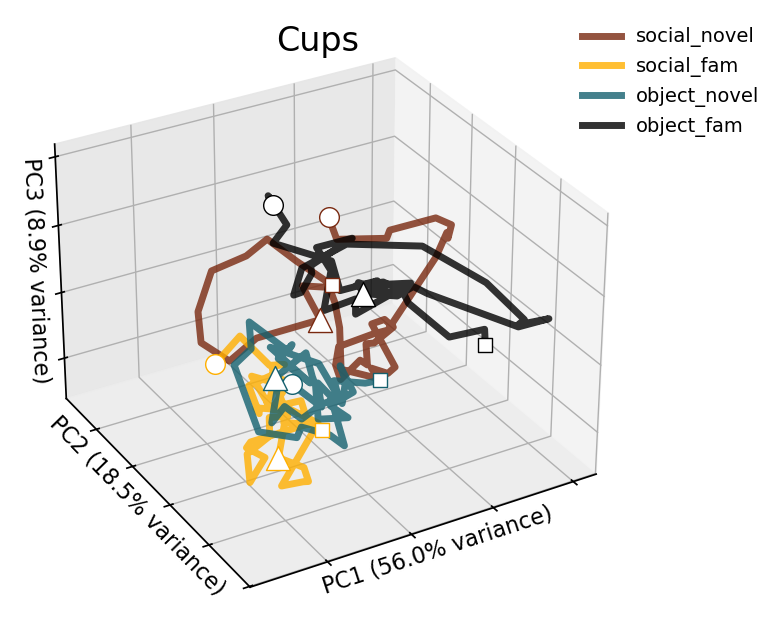

In [316]:
# 3D version
plot_pca_results_3d(
    pca_result=pca2_result, 
    title='Rehouse', 
    colors=[hex_2_rgb('#792910'),
            (1.0, 0.6862745098039216, 0.0),
            hex_2_rgb('#15616F'),
            'black'], 
    azim=60, 
    elev=30,
    condition_events=condition_events  # ✅ ADD THIS
)

In [323]:
from matplotlib.lines import Line2D

def plot_pca_results_3d_subset(
    pca_result, title, colors, azim, elev, conditions_to_plot, condition_events=None, save=False
):
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    condition_dict = pca_result.condition_dict
    PCA_matrix = pca_result.transformed_data
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    col_counter = 0
    
    for condition in conditions_to_plot:
        if condition not in condition_dict:
            print(f"Warning: {condition} not found in results")
            continue
        
        relevant_events = condition_events.get(condition, []) if condition_events else []
        condition_data = PCA_matrix[condition]
        matching_indices = [i for i in range(0, len(PCA_key), event_lengths) if PCA_key[i] in relevant_events]
        
        if not matching_indices:
            continue
        
        trajectories = [condition_data[idx:idx + event_lengths, :] for idx in matching_indices]
        avg_trajectory = np.mean(trajectories, axis=0)
        
        onset = int(pre_window - 1) if pre_window > 0 else 0
        end = int(event_end - 1)
        post = int(event_lengths - 1)
        
        ax.plot3D(
            avg_trajectory[:, 0], avg_trajectory[:, 1], avg_trajectory[:, 2],
            label=condition, color=colors[col_counter], linewidth=4, alpha=0.9
        )
        ax.scatter(avg_trajectory[0, 0], avg_trajectory[0, 1], avg_trajectory[0, 2],
                   marker="s", s=100, c="w", edgecolors=colors[col_counter])
        ax.scatter(avg_trajectory[onset, 0], avg_trajectory[onset, 1], avg_trajectory[onset, 2],
                   marker="^", s=150, c="w", edgecolors=colors[col_counter])
        ax.scatter(avg_trajectory[end, 0], avg_trajectory[end, 1], avg_trajectory[end, 2],
                   marker="o", s=120, c="w", edgecolors=colors[col_counter])
        if post_window != 0:
            ax.scatter(avg_trajectory[post, 0], avg_trajectory[post, 1], avg_trajectory[post, 2],
                       marker="D", s=150, c="w", edgecolors=colors[col_counter])
        col_counter += 1
    
    # Condition legend
    condition_legend = ax.legend(
        loc="upper left", bbox_to_anchor=(1.05, 1), frameon=False, fontsize=13, title="Conditions"
    )
    
    # Shape legend - only include markers that exist
    shape_handles = [
        Line2D([0], [0], color="black", marker="s", linestyle="None", label="Pre-event (□)", markersize=8),
        Line2D([0], [0], color="black", marker="^", linestyle="None", label="Onset (△)", markersize=8),
        Line2D([0], [0], color="black", marker="o", linestyle="None", label="End (○)", markersize=8),
    ]
    if post_window != 0:
        shape_handles.append(
            Line2D([0], [0], color="black", marker="D", linestyle="None", label="Post (◇)", markersize=8)
        )
    
    shape_legend = ax.legend(
        handles=shape_handles, loc="lower left", bbox_to_anchor=(1.05, -0.05),
        frameon=False, fontsize=12, title="Markers"
    )
    plt.gca().add_artist(condition_legend)
    
    # Extra padding so z-label + legend fit
    plt.subplots_adjust(right=0.75, bottom=0.15)
    ax.view_init(azim=azim, elev=elev)
    ax.set_title(f"{title}", fontsize=22, y=1)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    
    if save:
        plt.savefig(f"{title}.png", dpi=600, transparent=True, bbox_inches="tight")
    plt.show()


def plot_pca_results_2d_subset(
    pca_result, title, colors, legend_spot, conditions_to_plot, condition_events=None, save=False
):
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    condition_dict = pca_result.condition_dict
    PCA_matrix = pca_result.transformed_data
    
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    col_counter = 0
    
    for condition in conditions_to_plot:
        if condition not in condition_dict:
            print(f"Warning: {condition} not found in results")
            continue
        
        relevant_events = condition_events.get(condition, []) if condition_events else []
        condition_data = PCA_matrix[condition]
        matching_indices = [i for i in range(0, len(PCA_key), event_lengths) if PCA_key[i] in relevant_events]
        
        if not matching_indices:
            continue
        
        trajectories = [condition_data[idx:idx + event_lengths, :] for idx in matching_indices]
        avg_trajectory = np.mean(trajectories, axis=0)
        
        onset = int(pre_window - 1) if pre_window > 0 else 0
        end = int(event_end - 1)
        post = int(event_lengths - 1)
        
        ax.plot(
            avg_trajectory[:, 0], avg_trajectory[:, 1],
            label=condition, color=colors[col_counter], linewidth=4, alpha=0.9, zorder=1
        )
        ax.scatter(avg_trajectory[0, 0], avg_trajectory[0, 1],
                   marker="s", s=100, c="w", edgecolors=colors[col_counter], zorder=2)
        ax.scatter(avg_trajectory[onset, 0], avg_trajectory[onset, 1],
                   marker="^", s=150, c="w", edgecolors=colors[col_counter], zorder=3)
        ax.scatter(avg_trajectory[end, 0], avg_trajectory[end, 1],
                   marker="o", s=120, c="w", edgecolors=colors[col_counter], zorder=4)
        if post_window != 0:
            ax.scatter(avg_trajectory[post, 0], avg_trajectory[post, 1],
                       marker="D", s=150, c="w", edgecolors=colors[col_counter], zorder=5)
        col_counter += 1
    
    # Condition legend
    condition_legend = ax.legend(
        loc="upper left", bbox_to_anchor=(1.05, 1), frameon=False, fontsize=13, title="Conditions"
    )
    
    # Shape legend - only include markers that exist
    shape_handles = [
        Line2D([0], [0], color="black", marker="s", linestyle="None", label="Pre-event (□)", markersize=8),
        Line2D([0], [0], color="black", marker="^", linestyle="None", label="Onset (△)", markersize=8),
        Line2D([0], [0], color="black", marker="o", linestyle="None", label="End (○)", markersize=8),
    ]
    if post_window != 0:
        shape_handles.append(
            Line2D([0], [0], color="black", marker="D", linestyle="None", label="Post (◇)", markersize=8)
        )
    
    shape_legend = ax.legend(
        handles=shape_handles, loc="lower left", bbox_to_anchor=(1.05, -0.05),
        frameon=False, fontsize=12, title="Markers"
    )
    plt.gca().add_artist(condition_legend)
    
    # Extra padding so legend fits
    plt.subplots_adjust(right=0.75, bottom=0.15)
    
    ax.set_title(f"{title}", fontsize=22, y=1.01)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% var)", fontsize=14)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% var)", fontsize=14)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xticks([])
    
    if save:
        plt.savefig(f"{title}.png", dpi=600, transparent=True, bbox_inches="tight")
    plt.show()

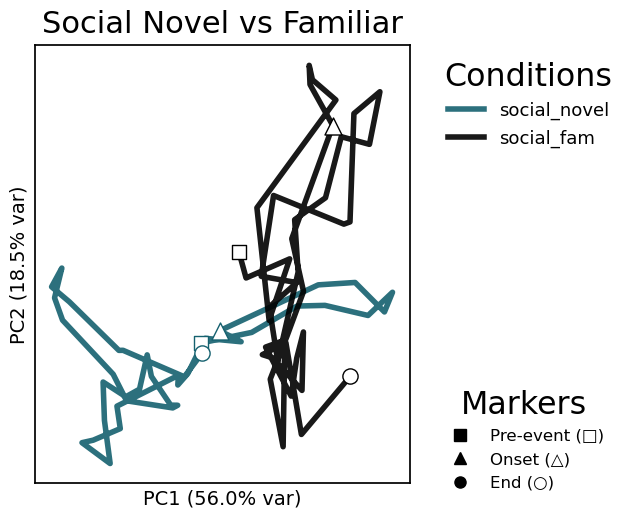

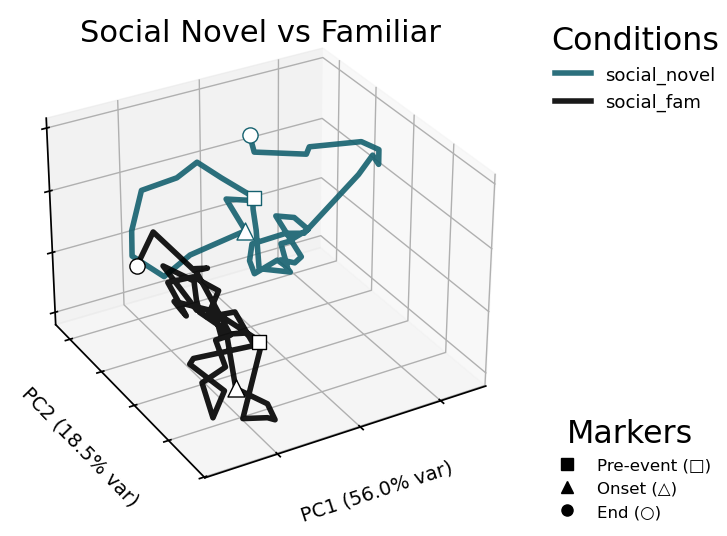

In [325]:
# 2D plot
plot_pca_results_2d_subset(
    pca_result=pca2_result,
    title='Social Novel vs Familiar',
    colors=[hex_2_rgb('#15616F'), 'black'],
    legend_spot=(0.67, 1),  # This parameter is no longer used but kept for compatibility
    conditions_to_plot=['social_novel', 'social_fam'],
    condition_events=condition_events
)

# 3D plot
plot_pca_results_3d_subset(
    pca_result=pca2_result,
    title='Social Novel vs Familiar',
    colors=[hex_2_rgb('#15616F'), 'black'],
    azim=60,
    elev=30,
    conditions_to_plot=['social_novel', 'social_fam'],
    condition_events=condition_events
)

In [347]:
sc.analyze(timebin=50, ignore_freq=0.5, smoothing_window = 500)

All set to analyze


Excluding 32_rehouse_d7_merged.rec with 4 neurons
Excluding 44_rehouse_d0_merged.rec with 4 neurons


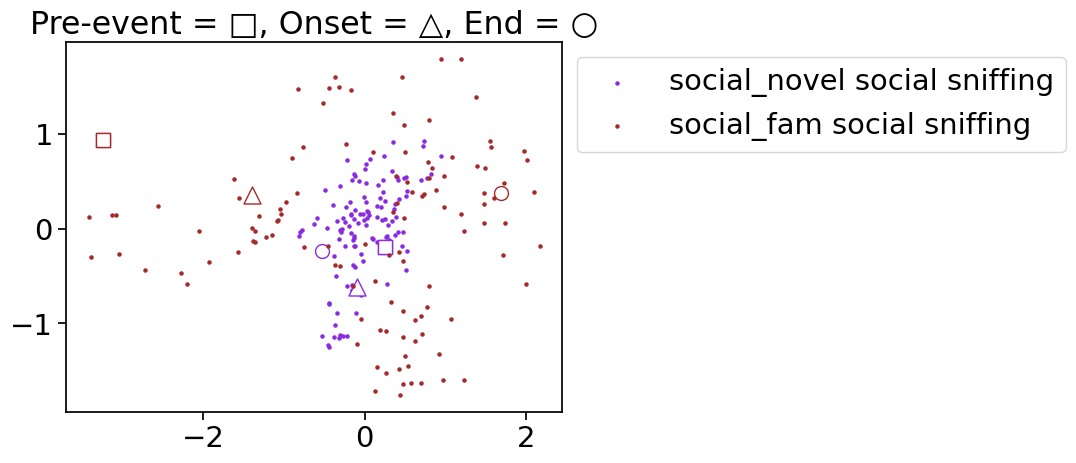

In [350]:
events = ["social sniffing"]
condition_dict = {
    "social_novel": [rec.name for rec in sc.recordings if "d0" in rec.name],
    "social_fam": [rec.name for rec in sc.recordings if "d7" in rec.name],
}

pca_50ms = pca_traj.condition_pca(
    sc,
    condition_dict=condition_dict,
    event_length=5,
    pre_window=1,
    min_neurons=5,
    events=events,
    d=2  # for 3D plot
)


In [355]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import numpy as np


def plot_pca_results_2d_conditioned(pca_result, title, colors, legend_spot, save=False):
    """
    Plot 2D PCA results for condition-averaged data (from condition_pca).
    Handles temporal structure with proper marker placement.
    """
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_matrix_dict = pca_result.transformed_data
    
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    col_counter = 0
    
    for cond_name, cond_data in PCA_matrix_dict.items():
        if cond_data.ndim < 2:
            continue  # skip bad entries
        
        # Calculate marker positions based on temporal structure
        onset = int(pre_window - 1) if pre_window > 0 else 0
        end = int(event_end - 1)
        post = int(event_lengths - 1)
        
        ax.plot(
            cond_data[:, 0], cond_data[:, 1],
            label=cond_name, color=colors[col_counter], linewidth=4, alpha=0.9, zorder=1
        )
        ax.scatter(cond_data[0, 0], cond_data[0, 1],
                   marker="s", s=100, c="w", edgecolors=colors[col_counter], zorder=2)
        ax.scatter(cond_data[onset, 0], cond_data[onset, 1],
                   marker="^", s=150, c="w", edgecolors=colors[col_counter], zorder=3)
        ax.scatter(cond_data[end, 0], cond_data[end, 1],
                   marker="o", s=120, c="w", edgecolors=colors[col_counter], zorder=4)
        if post_window != 0:
            ax.scatter(cond_data[post, 0], cond_data[post, 1],
                       marker="D", s=150, c="w", edgecolors=colors[col_counter], zorder=5)
        col_counter += 1
    
    # Condition legend
    condition_legend = ax.legend(
        loc="upper left", bbox_to_anchor=(1.05, 1), frameon=False, fontsize=13, title="Conditions"
    )
    
    # Shape legend - only include markers that exist
    shape_handles = [
        Line2D([0], [0], color="black", marker="s", linestyle="None", label="Pre-event (□)", markersize=8),
        Line2D([0], [0], color="black", marker="^", linestyle="None", label="Onset (△)", markersize=8),
        Line2D([0], [0], color="black", marker="o", linestyle="None", label="End (○)", markersize=8),
    ]
    if post_window != 0:
        shape_handles.append(
            Line2D([0], [0], color="black", marker="D", linestyle="None", label="Post (◇)", markersize=8)
        )
    
    shape_legend = ax.legend(
        handles=shape_handles, loc="lower left", bbox_to_anchor=(1.05, -0.05),
        frameon=False, fontsize=12, title="Markers"
    )
    plt.gca().add_artist(condition_legend)
    
    # Extra padding so legend fits
    plt.subplots_adjust(right=0.75, bottom=0.15)
    
    ax.set_title(f"{title}", fontsize=22, y=1.01)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% var)", fontsize=14)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% var)", fontsize=14)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xticks([])
    
    if save:
        plt.savefig(f"{title}.png", dpi=600, transparent=True, bbox_inches="tight")
    plt.show()


def plot_pca_results_3d_conditioned(pca_result, title, colors, azim, elev, save=False):
    """
    Plot 3D PCA results for condition-averaged data (from condition_pca).
    Handles temporal structure with proper marker placement.
    """
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_matrix_dict = pca_result.transformed_data
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    col_counter = 0
    
    for cond_name, cond_data in PCA_matrix_dict.items():
        if cond_data.ndim < 2:
            continue  # skip bad entries
        
        # Calculate marker positions based on temporal structure
        onset = int(pre_window - 1) if pre_window > 0 else 0
        end = int(event_end - 1)
        post = int(event_lengths - 1)
        
        ax.plot3D(
            cond_data[:, 0], cond_data[:, 1], cond_data[:, 2],
            label=cond_name, color=colors[col_counter], linewidth=4, alpha=0.9
        )
        ax.scatter(cond_data[0, 0], cond_data[0, 1], cond_data[0, 2],
                   marker="s", s=100, c="w", edgecolors=colors[col_counter])
        ax.scatter(cond_data[onset, 0], cond_data[onset, 1], cond_data[onset, 2],
                   marker="^", s=150, c="w", edgecolors=colors[col_counter])
        ax.scatter(cond_data[end, 0], cond_data[end, 1], cond_data[end, 2],
                   marker="o", s=120, c="w", edgecolors=colors[col_counter])
        if post_window != 0:
            ax.scatter(cond_data[post, 0], cond_data[post, 1], cond_data[post, 2],
                       marker="D", s=150, c="w", edgecolors=colors[col_counter])
        col_counter += 1
    
    # Condition legend
    condition_legend = ax.legend(
        loc="upper left", bbox_to_anchor=(1.05, 1), frameon=False, fontsize=13, title="Conditions"
    )
    
    # Shape legend - only include markers that exist
    shape_handles = [
        Line2D([0], [0], color="black", marker="s", linestyle="None", label="Pre-event (□)", markersize=8),
        Line2D([0], [0], color="black", marker="^", linestyle="None", label="Onset (△)", markersize=8),
        Line2D([0], [0], color="black", marker="o", linestyle="None", label="End (○)", markersize=8),
    ]
    if post_window != 0:
        shape_handles.append(
            Line2D([0], [0], color="black", marker="D", linestyle="None", label="Post (◇)", markersize=8)
        )
    
    shape_legend = ax.legend(
        handles=shape_handles, loc="lower left", bbox_to_anchor=(1.05, -0.05),
        frameon=False, fontsize=12, title="Markers"
    )
    plt.gca().add_artist(condition_legend)
    
    # Extra padding so z-label + legend fit
    plt.subplots_adjust(right=0.75, bottom=0.15)
    ax.view_init(azim=azim, elev=elev)
    ax.set_title(f"{title}", fontsize=22, y=1)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    
    if save:
        plt.savefig(f"{title}.png", dpi=600, transparent=True, bbox_inches="tight")
    plt.show()

def plot_pca_results_3d(pca_result, title, colors, azim, elev, condition_events=None, save=False):
    """
    Plot 3D PCA results. Works with both standard and condition-based PCA.
    """
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    
    # Check if this is condition-based PCA
    is_condition_pca = isinstance(pca_result.transformed_data, dict)
    
    col_counter = 0
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    
    if is_condition_pca:
        # Handle condition-based PCA
        condition_dict = pca_result.condition_dict
        PCA_matrix = pca_result.transformed_data
        
        # Iterate through conditions instead of all events
        for condition in condition_dict.keys():
            relevant_events = condition_events.get(condition, []) if condition_events else []
            
            # Find the first occurrence of a relevant event for this condition
            event_found = False
            for i in range(0, len(PCA_key), event_lengths):
                event_label = PCA_key[i]
                
                # Only plot if this event belongs to this condition
                if event_label in relevant_events:
                    event_found = True
                    onset = int(i + pre_window - 1)
                    end = int(i + event_end - 1)
                    post = int(i + event_lengths - 1)
                    
                    ax.plot3D(
                        PCA_matrix[condition][i : i + event_lengths, 0],
                        PCA_matrix[condition][i : i + event_lengths, 1],
                        PCA_matrix[condition][i : i + event_lengths, 2],
                        label=condition,
                        color=colors[col_counter],
                        linewidth=4,
                        alpha=0.9
                    )
                    ax.scatter(
                        PCA_matrix[condition][i, 0],
                        PCA_matrix[condition][i, 1],
                        PCA_matrix[condition][i, 2],
                        marker="s",
                        s=100,
                        c="w",
                        edgecolors=colors[col_counter],
                    )
                    ax.scatter(
                        PCA_matrix[condition][onset, 0],
                        PCA_matrix[condition][onset, 1],
                        PCA_matrix[condition][onset, 2],
                        marker="^",
                        s=150,
                        c="w",
                        edgecolors=colors[col_counter],
                    )
                    ax.scatter(
                        PCA_matrix[condition][end, 0],
                        PCA_matrix[condition][end, 1],
                        PCA_matrix[condition][end, 2],
                        marker="o",
                        s=120,
                        c="w",
                        edgecolors=colors[col_counter],
                    )
                    if post_window != 0:
                        ax.scatter(
                            PCA_matrix[condition][post, 0],
                            PCA_matrix[condition][post, 1],
                            PCA_matrix[condition][post, 2],
                            marker="D",
                            s=150,
                            c="w",
                            edgecolors=colors[col_counter],
                        )
                    break  # Only plot once per condition
            
            if event_found:
                col_counter += 1
    else:
        # Handle standard PCA (original code)
        PCA_matrix = pca_result.transformed_data
        
        for i in range(0, len(PCA_key), event_lengths):
            event_label = PCA_key[i]
            onset = int(i + pre_window - 1)
            end = int(i + event_end - 1)
            post = int(i + event_lengths - 1)
            
            ax.plot3D(
                PCA_matrix[i : i + event_lengths, 0],
                PCA_matrix[i : i + event_lengths, 1],
                PCA_matrix[i : i + event_lengths, 2],
                label=event_label,
                color=colors[col_counter],
                linewidth=4,
                alpha=0.9
            )
            ax.scatter(
                PCA_matrix[i, 0],
                PCA_matrix[i, 1],
                PCA_matrix[i, 2],
                marker="s",
                s=100,
                c="w",
                edgecolors=colors[col_counter],
            )
            ax.scatter(
                PCA_matrix[onset, 0],
                PCA_matrix[onset, 1],
                PCA_matrix[onset, 2],
                marker="^",
                s=150,
                c="w",
                edgecolors=colors[col_counter],
            )
            ax.scatter(
                PCA_matrix[end, 0],
                PCA_matrix[end, 1],
                PCA_matrix[end, 2],
                marker="o",
                s=120,
                c="w",
                edgecolors=colors[col_counter],
            )
            if post_window != 0:
                ax.scatter(
                    PCA_matrix[post, 0],
                    PCA_matrix[post, 1],
                    PCA_matrix[post, 2],
                    marker="D",
                    s=150,
                    c="w",
                    edgecolors=colors[col_counter],
                )
            col_counter += 1
    
    # Condition legend
    condition_legend = ax.legend(
        loc="upper left", bbox_to_anchor=(1.05, 1), frameon=False, fontsize=13, title="Conditions"
    )
    
    # Shape legend - only include markers that exist
    shape_handles = [
        Line2D([0], [0], color="black", marker="s", linestyle="None", label="Pre-event (□)", markersize=8),
        Line2D([0], [0], color="black", marker="^", linestyle="None", label="Onset (△)", markersize=8),
        Line2D([0], [0], color="black", marker="o", linestyle="None", label="End (○)", markersize=8),
    ]
    if post_window != 0:
        shape_handles.append(
            Line2D([0], [0], color="black", marker="D", linestyle="None", label="Post (◇)", markersize=8)
        )
    
    shape_legend = ax.legend(
        handles=shape_handles, loc="lower left", bbox_to_anchor=(1.05, -0.05),
        frameon=False, fontsize=12, title="Markers"
    )
    plt.gca().add_artist(condition_legend)
    
    # Extra padding so z-label + legend fit
    plt.subplots_adjust(right=0.75, bottom=0.15)
    ax.view_init(azim=azim, elev=elev)
    ax.set_title(f"{title}", fontsize=22, y=1)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_zlabel(f"PC3 ({pc_var[2]*100:.1f}% var)", fontsize=14, labelpad=10)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    
    if save:
        plt.savefig(f"{title}.png", dpi=600, transparent=True, bbox_inches="tight")
    plt.show()


def plot_pca_results_2d(pca_result, title, colors, legend_spot, condition_events=None, save=False):
    """
    Plot 2D PCA results. Works with both standard and condition-based PCA.
    """
    event_lengths = int(
        (pca_result.event_length + pca_result.pre_window + pca_result.post_window) * 1000 / pca_result.timebin
    )
    
    event_end = int((pca_result.event_length + pca_result.pre_window) * 1000 / pca_result.timebin)
    pre_window = pca_result.pre_window * 1000 / pca_result.timebin
    post_window = pca_result.post_window * 1000 / pca_result.timebin
    pc_var = pca_result.explained_variance
    PCA_key = pca_result.labels
    
    # Check if this is condition-based PCA
    is_condition_pca = isinstance(pca_result.transformed_data, dict)
    
    col_counter = 0
    
    # Create figure with updated size
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    
    if is_condition_pca:
        # Handle condition-based PCA
        condition_dict = pca_result.condition_dict
        PCA_matrix = pca_result.transformed_data
        
        # Iterate through conditions instead of all events
        for condition in condition_dict.keys():
            relevant_events = condition_events.get(condition, []) if condition_events else []
            
            # Find the first occurrence of a relevant event for this condition
            event_found = False
            for i in range(0, len(PCA_key), event_lengths):
                event_label = PCA_key[i]
                
                # Only plot if this event belongs to this condition
                if event_label in relevant_events:
                    event_found = True
                    onset = int(i + pre_window - 1)
                    end = int(i + event_end - 1)
                    post = int(i + event_lengths - 1)
                    
                    # Plot the continuous line with updated styling
                    ax.plot(
                        PCA_matrix[condition][i:i + event_lengths, 0],
                        PCA_matrix[condition][i:i + event_lengths, 1],
                        label=condition,
                        color=colors[col_counter],
                        linewidth=4,
                        alpha=0.9,
                        zorder=1
                    )
                    
                    # Add markers with updated sizes
                    ax.scatter(
                        PCA_matrix[condition][i, 0],
                        PCA_matrix[condition][i, 1],
                        marker="s",
                        s=100,
                        c="w",
                        edgecolors=colors[col_counter],
                        zorder=2
                    )
                    ax.scatter(
                        PCA_matrix[condition][onset, 0],
                        PCA_matrix[condition][onset, 1],
                        marker="^",
                        s=150,
                        c="w",
                        edgecolors=colors[col_counter],
                        zorder=3
                    )
                    ax.scatter(
                        PCA_matrix[condition][end, 0],
                        PCA_matrix[condition][end, 1],
                        marker="o",
                        s=120,
                        c="w",
                        edgecolors=colors[col_counter],
                        zorder=4
                    )
                    if post_window != 0:
                        ax.scatter(
                            PCA_matrix[condition][post, 0],
                            PCA_matrix[condition][post, 1],
                            marker="D",
                            s=150,
                            c="w",
                            edgecolors=colors[col_counter],
                            zorder=5
                        )
                    break  # Only plot once per condition
            
            if event_found:
                col_counter += 1
    else:
        # Handle standard PCA (original code)
        PCA_matrix = pca_result.transformed_data
        
        for i in range(0, len(PCA_key), event_lengths):
            event_label = PCA_key[i]
            onset = int(i + pre_window - 1)
            end = int(i + event_end - 1)
            post = int(i + event_lengths - 1)
            
            # Plot the continuous line with updated styling
            ax.plot(
                PCA_matrix[i:i + event_lengths, 0],
                PCA_matrix[i:i + event_lengths, 1],
                label=event_label,
                color=colors[col_counter],
                linewidth=4,
                alpha=0.9,
                zorder=1
            )
            
            # Add markers with updated sizes
            ax.scatter(
                PCA_matrix[i, 0],
                PCA_matrix[i, 1],
                marker="s",
                s=100,
                c="w",
                edgecolors=colors[col_counter],
                zorder=2
            )
            ax.scatter(
                PCA_matrix[onset, 0],
                PCA_matrix[onset, 1],
                marker="^",
                s=150,
                c="w",
                edgecolors=colors[col_counter],
                zorder=3
            )
            ax.scatter(
                PCA_matrix[end, 0],
                PCA_matrix[end, 1],
                marker="o",
                s=120,
                c="w",
                edgecolors=colors[col_counter],
                zorder=4
            )
            if post_window != 0:
                ax.scatter(
                    PCA_matrix[post, 0],
                    PCA_matrix[post, 1],
                    marker="D",
                    s=150,
                    c="w",
                    edgecolors=colors[col_counter],
                    zorder=5
                )
            col_counter += 1
    
    # Condition legend
    condition_legend = ax.legend(
        loc="upper left", bbox_to_anchor=(1.05, 1), frameon=False, fontsize=13, title="Conditions"
    )
    
    # Shape legend - only include markers that exist
    shape_handles = [
        Line2D([0], [0], color="black", marker="s", linestyle="None", label="Pre-event (□)", markersize=8),
        Line2D([0], [0], color="black", marker="^", linestyle="None", label="Onset (△)", markersize=8),
        Line2D([0], [0], color="black", marker="o", linestyle="None", label="End (○)", markersize=8),
    ]
    if post_window != 0:
        shape_handles.append(
            Line2D([0], [0], color="black", marker="D", linestyle="None", label="Post (◇)", markersize=8)
        )
    
    shape_legend = ax.legend(
        handles=shape_handles, loc="lower left", bbox_to_anchor=(1.05, -0.05),
        frameon=False, fontsize=12, title="Markers"
    )
    plt.gca().add_artist(condition_legend)
    
    # Extra padding so legend fits
    plt.subplots_adjust(right=0.75, bottom=0.15)
    
    ax.set_title(f"{title}", fontsize=22, y=1.01)
    ax.set_xlabel(f"PC1 ({pc_var[0]*100:.1f}% var)", fontsize=14)
    ax.set_ylabel(f"PC2 ({pc_var[1]*100:.1f}% var)", fontsize=14)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_xticks([])
    
    if save:
        plt.savefig(f"{title}.png", dpi=600, transparent=True, bbox_inches="tight")
    plt.show()

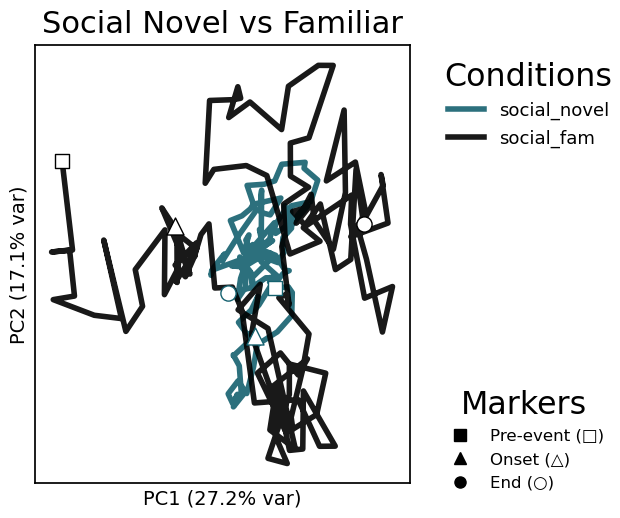

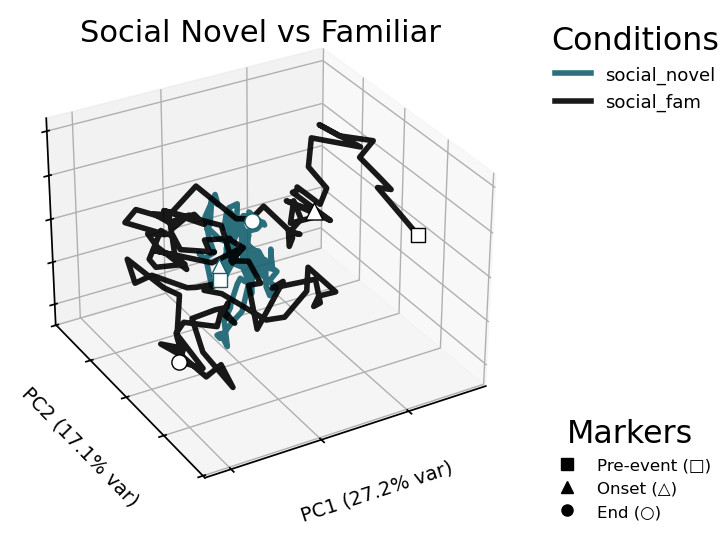

In [356]:
# 2D plot
plot_pca_results_2d_conditioned(
    pca_result=pca_50ms,
    title='Social Novel vs Familiar',
    colors=[hex_2_rgb('#15616F'), 'black'],
    legend_spot=(0.67, 1),  # Parameter kept for compatibility but not used
    save=False
)

# 3D plot (make sure d=3 in your condition_pca call)
plot_pca_results_3d_conditioned(
    pca_result=pca_50ms,
    title='Social Novel vs Familiar',
    colors=[hex_2_rgb('#15616F'), 'black'],
    azim=60,
    elev=30,
    save=False
)

In [291]:
!jupyter nbconvert --to script /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/pca_decode.ipynb

[NbConvertApp] Converting notebook /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/pca_decode.ipynb to script
[NbConvertApp] Writing 16874 bytes to /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/thomas-social-memory/single_cell/pca_decode.py
